In [1]:
import pathlib
import platform
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from segysak.segy import segy_header_scan, segy_header_scrape, get_segy_texthead
import xarray as xr
import bruges as bg

In [2]:
volume = xr.open_dataset("VOLUMES/Volume_Attributes.seisnc")

In [3]:
well_loc = [617263.72, 6392408.28]
wellbore = np.arange(1900, 2521, 4)
tops_twt = {
    "NORDLAND GP" : 76.71,
    "ROGALAND GP" : 563.74,
    "SHETLAND GP" : 646.61,
    "CROMER KNOLL GP" : 1109.08,
    "TAU FM" : 2044.62,
    "EGERSUND FM" : 2122.11,
    "SANDNES FM" : 2152.91,
    "BRYNE FM" : 2214.90,
    "TRIASSIC" : 2352.47,
    "TD" : 2520
}

# Approx. well location
iline = 4272 # 3800 - 4800 (2) : [236, :]
xline = 10486 # 10000 - 11000 (2) : [:, 243]

num_lines = 200

In [4]:
# Use a cropped volume to cut down on processing time when classifying
cube = volume.sel(iline=slice(iline-num_lines, iline+num_lines), xline=slice(xline-num_lines, xline+num_lines))
# cube

In [5]:
# Sample axis (e.g. TWT in ms)

# Define fixed iline and xline (vertical trajectory)
iline_borehole = np.full_like(wellbore, 4272)
xline_borehole = np.full_like(wellbore, 10486)

# Create xarray Dataset
well_ds = xr.Dataset(
    coords={
        "samples": wellbore,  # you may call this 'twt' instead
        "iline": ("samples", iline_borehole),
        "xline": ("samples", xline_borehole)
    },
    attrs={
        "well_name": "Well_A",
        "location_xy": well_loc,
        "trajectory": "vertical",
        "tops_twt": tops_twt
    }
)

# well_ds

# # Add a dummy gamma ray log
# well_ds["gamma_ray"] = ("samples", np.random.uniform(60, 120, len(wellbore)))

In [6]:
def sample_cube_near_well(cube: xr.Dataset, well: xr.Dataset, window=(1, 1, 4), attr_name="seismic"):
    """
    Extracts the mean value from a 3D cube in a window around each wellbore point.
    
    Parameters:
        cube: xarray.Dataset with a 3D DataArray named attr_name
        well: xarray.Dataset with iline, xline, and samples coordinates
        window: tuple (iline_halfwidth, xline_halfwidth, sample_halfwidth)
        attr_name: the name of the cube variable to sample (e.g. "seismic")
    
    Returns:
        xarray.DataArray: sampled values along wellbore
    """
    ilines = well["iline"].values
    xlines = well["xline"].values
    samples = well["samples"].values

    values = []
    for il, xl, s in zip(ilines, xlines, samples):
        subcube = cube[attr_name].sel(
            iline=slice(il - window[0], il + window[0]),
            xline=slice(xl - window[1], xl + window[1]),
            samples=slice(s - window[2], s + window[2])
        )
        # *** MEAN is used ****
        values.append(subcube.mean().item())

    return xr.DataArray(
        data=values,
        coords={"samples": samples},
        dims=["samples"],
        name=f"{attr_name}_sampled"
    )

In [7]:
# sample_cube_near_well(cube, well_ds, attr_name="Envelope")

# Horizon sculpting and windowed map extraction

In [ ]:
# NOTE: samples are positive so (-) moves "shallower" and (+) moves "deeper".
# Bryne window: 20 samples above to 150 samples below
mask = (cube.samples > cube.Bryne_TWT - 20) & (cube.samples < cube.Bryne_TWT + 150)
masked_data = cube.where(mask)

In [9]:
# Approx. well location
well_iline = 4272 # 3800 - 4800 (2) : [236, :]
well_xline = 10486 # 10000 - 11000 (2) : [:, 243]
# well_loc = [617263.72, 6392408.28]

In [ ]:
def plot_section(dataset, var, slice_dim, slice_at, samples=slice(2000, 2500), cmap="seismic_r"):
    """Plot a vertical section with Tau/Sandnes/Bryne horizon overlays.

    Slices at a fixed position along slice_dim and plots the orthogonal
    direction on the x-axis.
    """
    plot_dim = "xline" if slice_dim == "iline" else "iline"
    f, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
    (dataset[var]
     .sel({slice_dim: slice_at, "samples": samples})
     .plot.imshow(ax=ax, x=plot_dim, y="samples",
                  add_colorbar=True, interpolation="spline16",
                  robust=True, yincrease=False, cmap=cmap))
    for twt_var, color in [("Tau_TWT", "b"), ("Sandnes_TWT", "orange"), ("Bryne_TWT", "r")]:
        h = cube[twt_var].sel({slice_dim: slice_at})
        ax.plot(h[plot_dim], h.values, color=color)
    if plot_dim == "iline":
        ax.invert_xaxis()
    plt.show()

In [ ]:
plot_section(masked_data, "data", "iline", well_iline, slice(2000, 2450))

In [ ]:
plot_section(masked_data, "data", "xline", well_xline)

In [ ]:
plot_section(masked_data, "Phase", "xline", well_xline, cmap="Set1")

In [ ]:
plot_section(masked_data, "Envelope", "xline", well_xline, cmap="gist_ncar")

In [ ]:
plot_section(masked_data, "Energy", "xline", well_xline, cmap="gist_ncar")

In [ ]:
plot_section(masked_data, "InstFreq", "xline", well_xline, cmap="rainbow")

In [ ]:
plot_section(masked_data, "Quad", "xline", well_xline, cmap="gist_ncar")

In [19]:
cube.data_vars

Data variables:
    data         (iline, xline, samples) float32 81MB ...
    Envelope     (iline, xline, samples) float32 81MB ...
    Phase        (iline, xline, samples) float32 81MB ...
    Quad         (iline, xline, samples) float32 81MB ...
    InstFreq     (iline, xline, samples) float64 162MB ...
    InstAmp      (iline, xline, samples) float32 81MB ...
    ReflStr      (iline, xline, samples) float32 81MB ...
    Energy       (iline, xline, samples) float64 162MB ...
    Tau_TWT      (iline, xline) float64 323kB ...
    Sandnes_TWT  (iline, xline) float64 323kB ...
    Bryne_TWT    (iline, xline) float64 323kB 2.16e+03 2.16e+03 ... 2.211e+03

In [20]:
all_columns = ['Envelope', 'Phase', 'InstFreq',  'Energy', 'Quad', 'Sandnes_TWT']
feature_columns = ['Envelope', 'Phase', 'InstFreq',  'Energy', 'Quad']# 'ReflStr', 'InstAmp', = 'Envelope'

In [21]:
seis_sculpt = masked_data[feature_columns]

In [22]:
df = seis_sculpt.to_dataframe()
display(df)

Envelope  Phase  InstFreq  Energy  Quad   cdp_x    cdp_y
iline xline samples                                                          
4072  10286 1500.0        NaN    NaN       NaN     NaN   NaN  616421  6395827
            1504.0        NaN    NaN       NaN     NaN   NaN  616421  6395827
            1508.0        NaN    NaN       NaN     NaN   NaN  616421  6395827
            1512.0        NaN    NaN       NaN     NaN   NaN  616421  6395827
            1516.0        NaN    NaN       NaN     NaN   NaN  616421  6395827
...                       ...    ...       ...     ...   ...     ...      ...
4472  10686 3484.0        NaN    NaN       NaN     NaN   NaN  618120  6388964
            3488.0        NaN    NaN       NaN     NaN   NaN  618120  6388964
            3492.0        NaN    NaN       NaN     NaN   NaN  618120  6388964
            3496.0        NaN    NaN       NaN     NaN   NaN  618120  6388964
            3500.0        NaN    NaN       NaN     NaN   NaN  618120  6388964

[20240901 rows x 7 columns]

In [23]:
df = df.dropna()
# X_df = df[feature_columns].dropna()
X_orig = df[feature_columns].to_numpy()
X_orig.shape

(1717050, 5)

In [24]:
# Create a sample in order to crossplot to get an idea of correlation of features
# A better way to high grade features is through Principal Component Analysis (PCA)

# Number of random rows to sample
num_samples = 10000

# Generate random indices
indices = np.random.choice(X_orig.shape[0], size=num_samples, replace=False)

# Sample rows using the random indices
X_sample = X_orig[indices]

print("Original array:\n", X_orig.shape)
print("\nRandomly sampled rows:\n", X_sample.shape)

Original array:
 (1717050, 5)

Randomly sampled rows:
 (10000, 5)


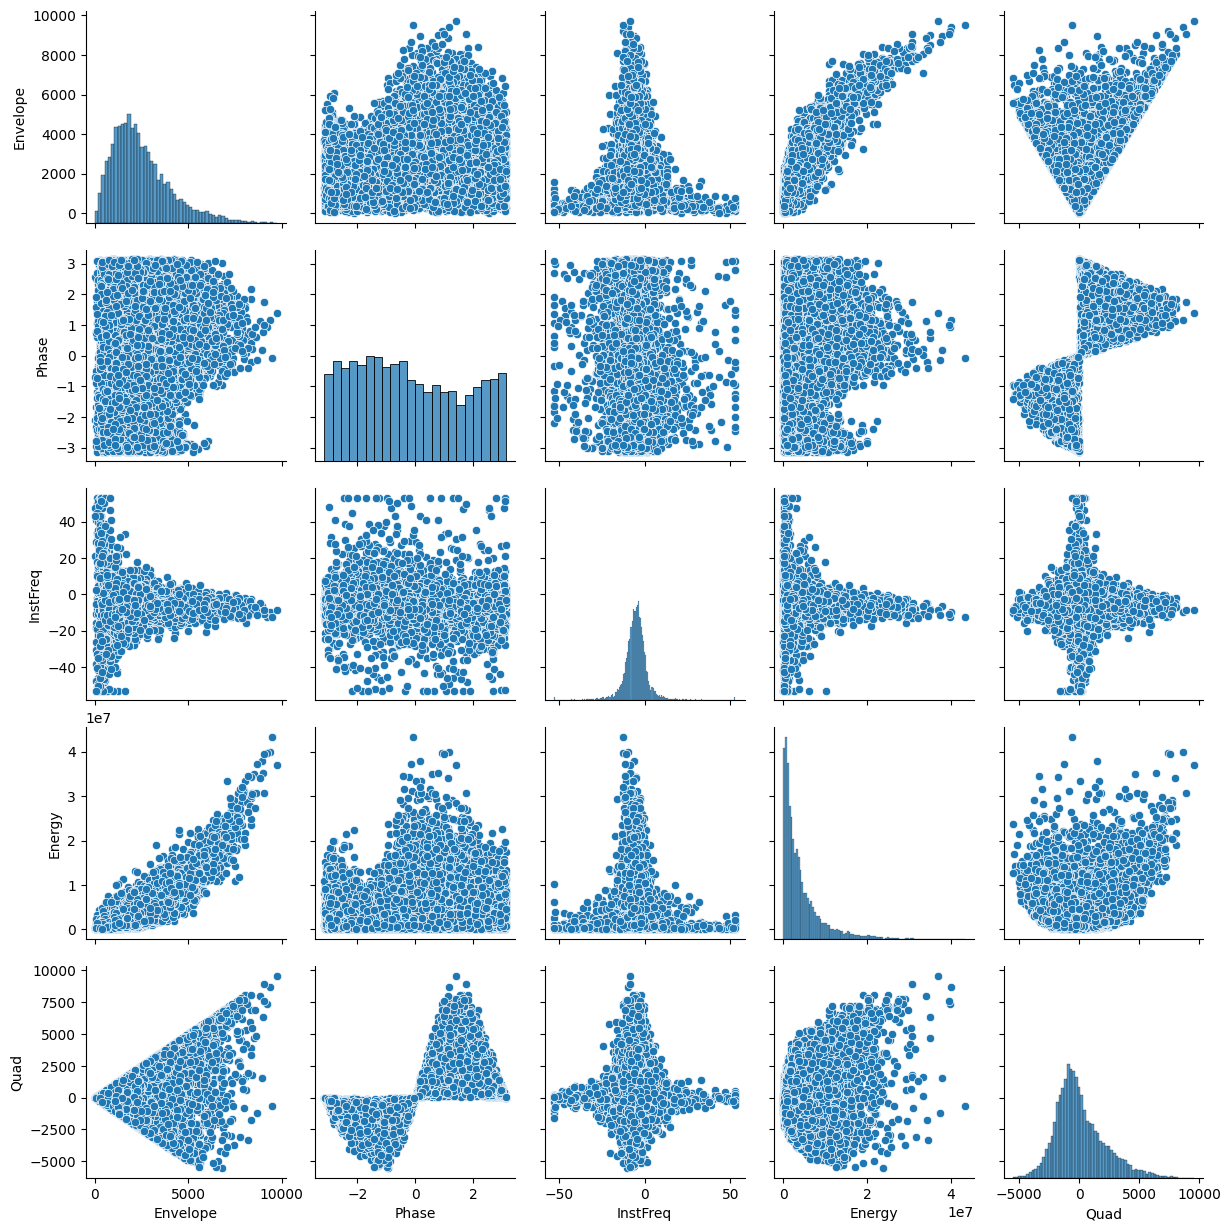

In [25]:
# Seaborn pairplot() to get a feel for feature correlation
import seaborn as sns
sns.pairplot(pd.DataFrame(X_sample, columns=feature_columns))

(array([2.61290e+05, 5.34882e+05, 4.31047e+05, 2.43900e+05, 1.26902e+05,
        6.67810e+04, 3.47470e+04, 1.37010e+04, 3.28500e+03, 5.15000e+02]),
 array([2.44565558e+00, 1.02846936e+03, 2.05449292e+03, 3.08051660e+03,
        4.10654053e+03, 5.13256396e+03, 6.15858789e+03, 7.18461182e+03,
        8.21063477e+03, 9.23665820e+03, 1.02626826e+04]),
 <BarContainer object of 10 artists>)

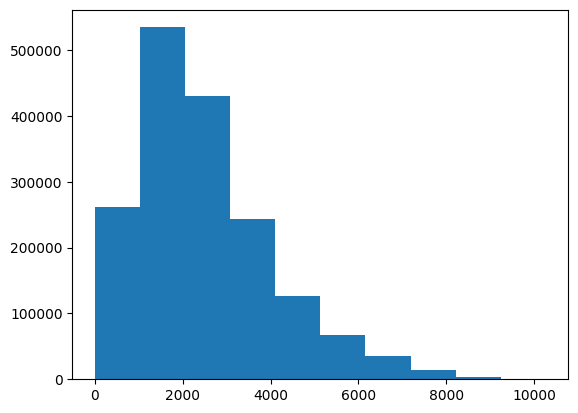

In [26]:
plt.hist(df.Envelope)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(3)
pca.fit(X_orig)

print(pca.components_)

X_pca = pca.transform(X_orig)
print(f"original shape: {X_orig.shape}")
print(f"transformed shape: {X_pca.shape}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
scaler = MinMaxScaler()
scaler.fit(X_orig)
X_scaled = scaler.transform(X_orig)

In [ ]:
X = X_scaled

In [ ]:
from minisom import MiniSom

In [ ]:
SOM_X_AXIS_NODES  = 5
SOM_Y_AXIS_NODES  = 5
SOM_N_VARIABLES  = X.shape[1]

In [ ]:
som = MiniSom(SOM_X_AXIS_NODES, SOM_Y_AXIS_NODES, SOM_N_VARIABLES)

In [ ]:
ALPHA = 0.5
DECAY_FUNC = 'linear_decay_to_zero'
SIGMA0 = 1.5
SIGMA_DECAY_FUNC = 'linear_decay_to_one'
NEIGHBORHOOD_FUNC = 'triangle'
DISTANCE_FUNC = 'euclidean'
TOPOLOGY = 'rectangular'
RANDOM_SEED = 123

In [ ]:
som = MiniSom(
        SOM_X_AXIS_NODES,
        SOM_Y_AXIS_NODES,
        SOM_N_VARIABLES,
        sigma=SIGMA0,
        learning_rate=ALPHA,
        neighborhood_function=NEIGHBORHOOD_FUNC,
        activation_distance=DISTANCE_FUNC,
        topology=TOPOLOGY,
        sigma_decay_function = SIGMA_DECAY_FUNC,
        decay_function = DECAY_FUNC,
        random_seed=RANDOM_SEED,
        )

In [ ]:
N_ITERATIONS = 5000
som.train_random(X, N_ITERATIONS, verbose=True)  

In [ ]:
# create the grid
plt.figure(figsize=(7, 6))
#plot the distance map
plt.pcolor(som.distance_map().T, cmap='gist_yarg') 
# show the color bar
plt.axis("equal")
plt.colorbar()
plt.show()

In [ ]:
# Vectorised BMU assignment (avoids slow Python loop over ~1.7M samples)
dists = som._distance_from_weights(X)
bmu_labels = np.array([
    np.unravel_index(d.argmin(), (SOM_X_AXIS_NODES, SOM_Y_AXIS_NODES))
    for d in dists
])

In [ ]:
# Convert 2D BMU coordinates into 1D labels
labels = np.ravel_multi_index(np.array(bmu_labels).T, dims=(SOM_X_AXIS_NODES, SOM_Y_AXIS_NODES))

In [ ]:
df['som_labels2'] = labels
display(df)

In [ ]:
SOM = df.to_xarray()

In [ ]:
SOM

In [ ]:
cube["SOM_Sandnes5x5"] = SOM.som_labels2
cube

In [ ]:
plot_section(cube, "SOM_Sandnes5x5", "xline", well_xline, slice(2000, 2300), "gist_ncar")

In [ ]:
cube.seisio.to_segy(
    "VOLUMES/SOM_Sandnes5x5.segy",
    data_var="SOM_Sandnes5x5",
    trace_header_map={"cdp_x": 73, "cdp_y": 77},
    iline=189,
    xline=193,
)

## Backup

In [ ]:
# Create a color map based on the SOM weights
weights = som.get_weights()
color_map = np.zeros((SOM_X_AXIS_NODES, SOM_Y_AXIS_NODES, 3))  # Assuming 3 features for RGB visualization

for i in range(SOM_X_AXIS_NODES):
    for j in range(SOM_Y_AXIS_NODES):
        color_map[i, j] = weights[i, j]  # Assign weights as RGB values

# Plot the SOM with a color bar
plt.figure(figsize=(8, 8))
plt.imshow(color_map, interpolation='nearest')
plt.colorbar(label='Feature Intensity')
plt.title('Self-Organizing Map with Color Map')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(6, 1), layout='constrained')

#cmap = mpl.cm.viridis
#cmap = mpl.cm.jet
#cmap = mpl.cm.hsv
cmap = mpl.cm.gist_ncar_r
bounds = labels
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=ax, orientation='horizontal',
             label="Discrete intervals with extend='both' keyword")

# Is the SOM cross-plot like that because of the removal of NANs?

In [ ]:
cube["SOM_Sandnes5x5"].plot()

In [ ]:
# plt.imshow(bryne_som)

In [ ]:
sandnes_som = cube["SOM_Sandnes5x5"].interp({"samples": cube.Sandnes_TWT}, method="linear")
sandnes_som

In [ ]:
fig = plt.figure(figsize=(12, 12))
axs = plt.subplot()
mesh = axs.pcolormesh(
    sandnes_som.cdp_x.values,
    sandnes_som.cdp_y.values,
    sandnes_som.values,
    shading="auto",
    cmap="gist_ncar"
)
plt.plot(well_loc[0], well_loc[1],'ro') 

axs.set_aspect(1)
_ = plt.colorbar(mesh, orientation="horizontal")

In [ ]:
# cube.to_netcdf('Volume_Attributes2.seisnc')